<div style="border:solid green 2px; padding: 20px"> <h1 style="color:green; margin-bottom:20px">Reviewers comment v1</h1>

Hello Hillary!

I'm happy to review your project today 🙌

My name is **Justino Imbert** ([this](https://hub.tripleten.com/u/125e88ae) is my Hub profile) and today I'll be reviewing your project!


You can find my comments under the heading **«Review»**. I will categorize my comments in green, blue or red boxes like this:

<div class="alert alert-success">
    <b>Success:</b> if everything is done successfully
</div>
<div class="alert alert-warning">
    <b>Remarks:</b> if I can give some recommendations or ways to improve the project
</div>
<div class="alert alert-danger">
    <b>Needs fixing:</b> if the block requires some corrections. Work cant be accepted with the red comments
</div>

Please dont remove my comments :) If you have any questions dont hesitate to respond to my comments in a different section. 
<div class="alert alert-info"> <b>Student comments:</b> For example like this</div>   


<div class="alert alert-block alert-info">
<b>Reviewer's comment v1:</b> </a>

You are doing a great job in this project! I left you some comments for you to address before I can approve it!

Looking forward to reviewing your next submission! Best of luck!
    
</div>


<div class="alert alert-block alert-info">
<b>Reviewer's comment v2:</b> </a>

Amazing job with this submission! I'm approving this project!

Congrats and I wish you the best of luck in the following sprints!

Looking forward to reviewing your future work!
    
</div>


Rusty Bargain used car sales service is developing an app to attract new customers. In that app, you can quickly find out the market value of your car. You have access to historical data: technical specifications, trim versions, and prices. You need to build the model to determine the value. 

Rusty Bargain is interested in:

- the quality of the prediction;
- the speed of the prediction;
- the time required for training

The main point of this step is to compare gradient boosting methods with random forest, decision tree, and linear regression.

## Data preparation

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split
import time

from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from catboost import CatBoostRegressor

from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, f1_score, classification_report, mean_absolute_error

In [2]:
#import and checking the initial data
data = pd.read_csv("/datasets/car_data.csv")
#data = pd.read_csv("/Users/hillary/Downloads/car_data.csv")
data.info()
display(data)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 354369 entries, 0 to 354368
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   DateCrawled        354369 non-null  object
 1   Price              354369 non-null  int64 
 2   VehicleType        316879 non-null  object
 3   RegistrationYear   354369 non-null  int64 
 4   Gearbox            334536 non-null  object
 5   Power              354369 non-null  int64 
 6   Model              334664 non-null  object
 7   Mileage            354369 non-null  int64 
 8   RegistrationMonth  354369 non-null  int64 
 9   FuelType           321474 non-null  object
 10  Brand              354369 non-null  object
 11  NotRepaired        283215 non-null  object
 12  DateCreated        354369 non-null  object
 13  NumberOfPictures   354369 non-null  int64 
 14  PostalCode         354369 non-null  int64 
 15  LastSeen           354369 non-null  object
dtypes: int64(7), object(

,DateCrawled,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Mileage,RegistrationMonth,FuelType,Brand,NotRepaired,DateCreated,NumberOfPictures,PostalCode,LastSeen
0,24/03/2016 11:52,480,NaN,1993,manual,0,golf,150000,0,petrol,volkswagen,NaN,24/03/2016 00:00,0,70435,07/04/2016 03:16
1,24/03/2016 10:58,18300,coupe,2011,manual,190,NaN,125000,5,gasoline,audi,yes,24/03/2016 00:00,0,66954,07/04/2016 01:46
2,14/03/2016 12:52,9800,suv,2004,auto,163,grand,125000,8,gasoline,jeep,NaN,14/03/2016 00:00,0,90480,05/04/2016 12:47
3,17/03/2016 16:54,1500,small,2001,manual,75,golf,150000,6,petrol,volkswagen,no,17/03/2016 00:00,0,91074,17/03/2016 17:40
4,31/03/2016 17:25,3600,small,2008,manual,69,fabia,90000,7,gasoline,skoda,no,31/03/2016 00:00,0,60437,06/04/2016 10:17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
354364,21/03/2016 09:50,0,NaN,2005,manual,0,colt,150000,7,petrol,mitsubishi,yes,21/03/2016 00:00,0,2694,21/03/2016 10:42
354365,14/03/2016 17:48,2200,NaN,2005,NaN,0,NaN,20000,1,NaN,sonstige_autos,NaN,14/03/2016 00:00,0,39576,06/04/2016 00:46
354366,05/03/2016 19:56,1199,convertible,2000,auto,101,fortwo,125000,3,petrol,smart,no,05/03/2016 00:00,0,26135,11/03/2016 18:17
354367,19/03/2016 18:57,9200,bus,1996,manual,102,transporter,150000,3,gasoline,volkswagen,no,19/03/2016 00:00,0,87439,07/04/2016 07:15


In [3]:
#check for missing values
display(data.isna().sum())
#calculate how large are they compare to the real values
print()
print("Missing values percentage:")
display(data.isna().sum()/len(data))


DateCrawled              0
Price                    0
VehicleType          37490
RegistrationYear         0
Gearbox              19833
Power                    0
Model                19705
Mileage                  0
RegistrationMonth        0
FuelType             32895
Brand                    0
NotRepaired          71154
DateCreated              0
NumberOfPictures         0
PostalCode               0
LastSeen                 0
dtype: int64


Missing values percentage:


DateCrawled          0.000000
Price                0.000000
VehicleType          0.105794
RegistrationYear     0.000000
Gearbox              0.055967
Power                0.000000
Model                0.055606
Mileage              0.000000
RegistrationMonth    0.000000
FuelType             0.092827
Brand                0.000000
NotRepaired          0.200791
DateCreated          0.000000
NumberOfPictures     0.000000
PostalCode           0.000000
LastSeen             0.000000
dtype: float64

In [4]:
#Droping columns that won't affect the predicition of the car price
data= data.drop(columns = ["NumberOfPictures", "DateCrawled","LastSeen","PostalCode","DateCreated"])
display(data)

,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Mileage,RegistrationMonth,FuelType,Brand,NotRepaired
0,480,NaN,1993,manual,0,golf,150000,0,petrol,volkswagen,NaN
1,18300,coupe,2011,manual,190,NaN,125000,5,gasoline,audi,yes
2,9800,suv,2004,auto,163,grand,125000,8,gasoline,jeep,NaN
3,1500,small,2001,manual,75,golf,150000,6,petrol,volkswagen,no
4,3600,small,2008,manual,69,fabia,90000,7,gasoline,skoda,no
...,...,...,...,...,...,...,...,...,...,...,...
354364,0,NaN,2005,manual,0,colt,150000,7,petrol,mitsubishi,yes
354365,2200,NaN,2005,NaN,0,NaN,20000,1,NaN,sonstige_autos,NaN
354366,1199,convertible,2000,auto,101,fortwo,125000,3,petrol,smart,no
354367,9200,bus,1996,manual,102,transporter,150000,3,gasoline,volkswagen,no


In [5]:
#since most of our missing categorical data is under 20%, consider filling in the gap with "Unknown"
data['VehicleType'] = data['VehicleType'].fillna('Unknown', inplace = False)
data['Gearbox'] = data['Gearbox'].fillna('Unknown', inplace = False)
data['FuelType'] = data['FuelType'].fillna('Unknown', inplace = False)
data['Model'] = data['Model'].fillna('Unknown', inplace = False)
data['NotRepaired'] = data['NotRepaired'].fillna('Unknown', inplace = False)

#displaying data to double check
data.info()
display(data)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 354369 entries, 0 to 354368
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   Price              354369 non-null  int64 
 1   VehicleType        354369 non-null  object
 2   RegistrationYear   354369 non-null  int64 
 3   Gearbox            354369 non-null  object
 4   Power              354369 non-null  int64 
 5   Model              354369 non-null  object
 6   Mileage            354369 non-null  int64 
 7   RegistrationMonth  354369 non-null  int64 
 8   FuelType           354369 non-null  object
 9   Brand              354369 non-null  object
 10  NotRepaired        354369 non-null  object
dtypes: int64(5), object(6)
memory usage: 29.7+ MB


,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Mileage,RegistrationMonth,FuelType,Brand,NotRepaired
0,480,Unknown,1993,manual,0,golf,150000,0,petrol,volkswagen,Unknown
1,18300,coupe,2011,manual,190,Unknown,125000,5,gasoline,audi,yes
2,9800,suv,2004,auto,163,grand,125000,8,gasoline,jeep,Unknown
3,1500,small,2001,manual,75,golf,150000,6,petrol,volkswagen,no
4,3600,small,2008,manual,69,fabia,90000,7,gasoline,skoda,no
...,...,...,...,...,...,...,...,...,...,...,...
354364,0,Unknown,2005,manual,0,colt,150000,7,petrol,mitsubishi,yes
354365,2200,Unknown,2005,Unknown,0,Unknown,20000,1,Unknown,sonstige_autos,Unknown
354366,1199,convertible,2000,auto,101,fortwo,125000,3,petrol,smart,no
354367,9200,bus,1996,manual,102,transporter,150000,3,gasoline,volkswagen,no


<div class="alert alert-block alert-success">
<b>Reviewer's comment v1:</b> </a>

You did an excellent job with the data preparation!

</div>


### EDA
Displaying the dataframe to see if there are any unbalance distribution

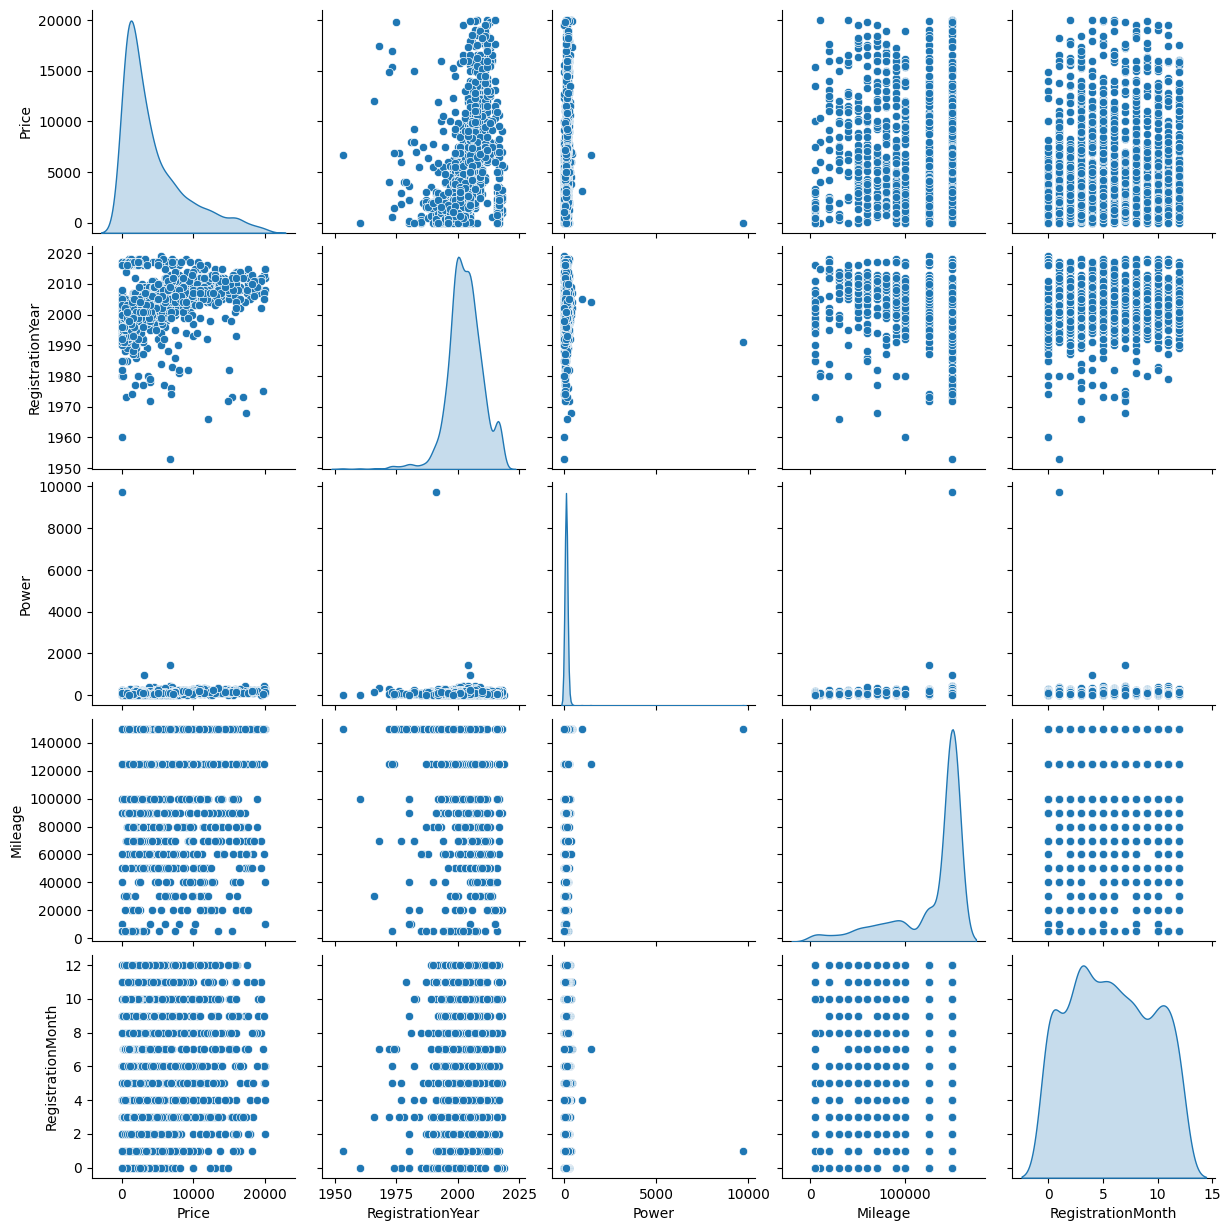

In [6]:
#Using pairplot to generate kde graphs for a better overview of the data distribution
sns.pairplot(data.sample(2000), diag_kind='kde')

In [7]:
#display data price here to see skewage

- We can see that the pairplot have clean  structure: the diagonal distributions + scatterplots between all numeric variables.
- The KDE curves on the diagonal show that some features (like Price and Mileage) have skewed distributions — that’s useful insight for preprocessing later.
- We can tell that some numeric columns don’t have a strong continuous relationship — they look like “bands” or “stripes.”

- ( mabybe needed to scale and encode the data) 


<div class="alert alert-block alert-success">
<b>Reviewer's comment v1:</b> </a>

Great job! Looking good!    
</div>


### Split, Encode and Balance data

In [8]:
#Declare target and feature variable
target = data['Price']
features = data.drop('Price', axis = 1)

In [9]:
#split training, test and valid set 

# First, split into train + temp (valid + test)
features_train, features_temp, target_train, target_temp = train_test_split(features, target, test_size=0.4, random_state=42)

# Then, split the temp set equally into validation and test
features_valid, features_test, target_valid, target_test = train_test_split(features_temp, target_temp, test_size=0.5, random_state=42)


<div class="alert alert-block alert-success">
<b>Reviewer's comment v1:</b> </a>

Amazing job splitting the data!
    
</div>


In [10]:
#using ordinal encoder to encoding data since most of the data are catergorical 
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

#decalre a list of datas we want to encode
cat_cols = ['VehicleType', 'Gearbox', 'Model', 'FuelType', 'Brand', 'NotRepaired']
num_cols = ['Price', 'RegistrationYear', 'Power','Mileage', 'RegistrationMonth']

#make a copy and encode the features after spliting
ord_features_train = features_train.copy()
ord_features_test = features_test.copy()
ord_features_valid = features_valid.copy()

#ordinal encoder
ord_features_train[cat_cols] = encoder.fit_transform(ord_features_train[cat_cols])
ord_features_test[cat_cols] = encoder.fit_transform(ord_features_test[cat_cols])
ord_features_valid[cat_cols] = encoder.fit_transform(ord_features_valid[cat_cols])


<div class="alert alert-block alert-warning">
<b>Reviewer's comment v1:</b> </a>

You should try to avoid using `fit_transform()` on all datasets separately! It’s better to fit only on the training data and then transform the others!

This helps avoid data leakage and ensures a more reliable evaluation of your model!

</div>


In [11]:
#checking for data leakage
print(ord_features_train.head())
print()
print(ord_features_valid.head())
print()
print(ord_features_test.head())

        VehicleType  RegistrationYear  Gearbox  Power  Model  Mileage  \
12056           6.0              1996      2.0     75  121.0   125000   
55604           1.0              2000      2.0    140  199.0   150000   
235520          2.0              2000      2.0     75  144.0   150000   
210358          8.0              1998      2.0     88   10.0   150000   
353679          2.0              1996      2.0     71   43.0   150000   

        RegistrationMonth  FuelType  Brand  NotRepaired  
12056                   0       7.0   30.0          2.0  
55604                   1       5.0   27.0          1.0  
235520                  6       7.0   38.0          1.0  
210358                  3       7.0   25.0          1.0  
353679                  2       7.0   24.0          1.0  

        VehicleType  RegistrationYear  Gearbox  Power  Model  Mileage  \
144155          5.0              2012      2.0    156   35.0     5000   
81315           1.0              2011      2.0    116  167.0    90

In [12]:
#encode and scale data for Linear Regressiong training
#create a new variable for one hot encoded features  
ohe_features_train = pd.get_dummies(features_train, columns = cat_cols)
ohe_features_valid = pd.get_dummies(features_valid, columns = cat_cols)
ohe_features_test =pd.get_dummies(features_test, columns = cat_cols)

# Align columns to ensure same structure across splits
ohe_features_train, ohe_features_valid = ohe_features_train.align(ohe_features_valid, join='left', axis=1, fill_value=0)
ohe_features_train, ohe_features_test  = ohe_features_train.align(ohe_features_test,  join='left', axis=1, fill_value=0)

ohe_features_train = ohe_features_train.astype(float)
ohe_features_valid = ohe_features_valid.astype(float)
ohe_features_test  = ohe_features_test.astype(float)


In [13]:
#scale the data
scaler = StandardScaler()

# Fit only on training data
scaler.fit(ohe_features_train)

# Then transform validation and test sets using the same scaler
ohe_features_train_scaled = scaler.transform(ohe_features_train)
ohe_features_valid_scaled = scaler.transform(ohe_features_valid)
ohe_features_test_scaled  = scaler.transform(ohe_features_test)


In [14]:
#check for data leakage
print(ohe_features_train.head())
print()
print(ohe_features_valid.head())
print()
print(ohe_features_test.head())

        RegistrationYear  Power   Mileage  RegistrationMonth  \
12056             1996.0   75.0  125000.0                0.0   
55604             2000.0  140.0  150000.0                1.0   
235520            2000.0   75.0  150000.0                6.0   
210358            1998.0   88.0  150000.0                3.0   
353679            1996.0   71.0  150000.0                2.0   

        VehicleType_Unknown  VehicleType_bus  VehicleType_convertible  \
12056                   0.0              0.0                      0.0   
55604                   0.0              1.0                      0.0   
235520                  0.0              0.0                      1.0   
210358                  0.0              0.0                      0.0   
353679                  0.0              0.0                      1.0   

        VehicleType_coupe  VehicleType_other  VehicleType_sedan  ...  \
12056                 0.0                0.0                0.0  ...   
55604                 0.0       

## Model training

In [15]:
#define a function to calculate the training time for each model
def train_and_time(model, X_train, y_train):
    start = time.time()
    model.fit(X_train, y_train)
    end = time.time()
    duration = end - start
    print(f"{model.__class__.__name__} training time: {duration:.2f} seconds")
    return model, duration

In [16]:
#declare training model 
rf = RandomForestRegressor(n_estimators=3, random_state=54321)
dt = DecisionTreeRegressor(max_depth= 3, random_state=54321)
lg = LinearRegression()
cbr = CatBoostRegressor(loss_function="RMSE", depth=6,learning_rate=0.1,random_state=54321, verbose = 0)

In [17]:
#training random forest model
#using ordinal encoding features
rf.fit(ord_features_train, target_train) 

rf_test_pred = rf.predict(ord_features_test)
rf_valid_pred = rf.predict(ord_features_valid)

# Evaluate the model
rmse_valid = np.sqrt(mean_squared_error(target_valid, rf_valid_pred))
rmse_test = np.sqrt(mean_squared_error(target_test, rf_test_pred))

print('Validation test for Random Forest Regressor Model:')
print(f"Validation RMSE: {rmse_valid:.4f}")
print(f"Test RMSE: {rmse_test:.4f}")
print(f"Validation R²: {r2_score(target_valid, rf_valid_pred):.4f}")
print(f"Test R²: {r2_score(target_test, rf_test_pred):.4f}")
rf_model, rf_time = train_and_time(RandomForestRegressor(random_state=54321), ord_features_train, target_train)

Validation test for Random Forest Regressor Model:
Validation RMSE: 2039.0880
Test RMSE: 2021.5055
Validation R²: 0.7955
Test R²: 0.7997
RandomForestRegressor training time: 48.90 seconds


In [18]:
#training decision tree model
#Using ordinal encoding features
dt.fit(ord_features_train, target_train) #updated to DecisionTreeRegression

dt_valid_pred = dt.predict(ord_features_valid)
dt_test_pred = dt.predict(ord_features_test)

#sanity check
# Evaluate performance
rmse_valid = np.sqrt(mean_squared_error(target_valid, dt_valid_pred))
rmse_test = np.sqrt(mean_squared_error(target_test, dt_test_pred))

print('Validation test for Decision Tree Regressor Model:')
print(f"Validation RMSE: {rmse_valid:.4f}")
print(f"Test RMSE: {rmse_test:.4f}")
print(f"Validation R²: {r2_score(target_valid, dt_valid_pred):.4f}")
print(f"Test R²: {r2_score(target_test, dt_test_pred):.4f}")
dt_model, dt_time = train_and_time(DecisionTreeRegressor(random_state = 54321), ord_features_train, target_train)

Validation test for Decision Tree Regressor Model:
Validation RMSE: 3054.0132
Test RMSE: 3037.9675
Validation R²: 0.5412
Test R²: 0.5477
DecisionTreeRegressor training time: 0.75 seconds


<div class="alert alert-block alert-danger">
<b>Reviewer's comment v1:</b> </a>

For regression tasks (like predicting price), it’s better to use DecisionTreeRegressor instead of DecisionTreeClassifier! That will give you more meaningful and continuous predictions!

</div>


<div class="alert alert-block alert-success">
<b>Reviewer's comment v2:</b> </a>

Excellent job addressing this comment!

</div>


In [ ]:
#training linear regression model
#using one hot encoding features
lg.fit(ohe_features_train, target_train)

lg_valid_pred = lg.predict(ohe_features_valid)
lg_test_pred = lg.predict(ohe_features_test)

#sanity check
# Evaluate performance
rmse_valid = np.sqrt(mean_squared_error(target_valid, lg_valid_pred))
rmse_test = np.sqrt(mean_squared_error(target_test, lg_test_pred))

print('Validation test for Linear Regression Model:')
print(f"Validation RMSE: {rmse_valid:.4f}")
print(f"Test RMSE: {rmse_test:.4f}")
print(f"Validation R²: {r2_score(target_valid, lg_valid_pred):.4f}")
print(f"Test R²: {r2_score(target_test, lg_test_pred):.4f}")
lg_model, lg_time = train_and_time(LinearRegression(), ohe_features_train, target_train)

In [ ]:
# Fit model with categorical info
cbr.fit(ord_features_train, target_train,)

# Predict
pred_valid = cbr.predict(ord_features_valid)
pred_test  = cbr.predict(ord_features_test)

# Evaluate with classification metrics
print('Validation test for CatBoost Regressor:')
print("Validation RMSE:", mean_squared_error(target_valid, pred_valid, squared=False))
print("Test RMSE:", mean_squared_error(target_test, pred_test, squared=False))
print("Validation R²:", r2_score(target_valid, pred_valid))
print("Test R²:", r2_score(target_test, pred_test))
cbr_model, cbr_time = train_and_time(CatBoostRegressor(random_state=54321), ord_features_train, target_train)

## Model analysis

After training and evaluating four regression models—Decision Tree, Linear Regression, Random Forest, and CatBoost—the results indicate that the CatBoost Regressor achieved the best overall performance. It produced the lowest RMSE (≈1779.78) and the highest R² score (≈0.84), demonstrating strong predictive accuracy and generalization across both validation and test sets. The Random Forest Regressor followed closely with an R² of 0.80 but required significantly longer training time. Linear Regression provided moderate performance and served as a useful baseline, while the Decision Tree Regressor underperformed with low R² values, suggesting it struggled to capture complex relationships in the data. Overall, the CatBoost model proved to be the most reliable and efficient choice for predicting car prices in this dataset.

<div class="alert alert-block alert-success">
<b>Reviewer's comment v1:</b> </a>

Nice summary!

</div>


<div class="alert alert-block alert-danger">
<b>Reviewer's comment v1:</b> </a>

You should also analyze the speed for each model! The task asks to analyze both speed and quality! (Project instructions 3.)

</div>


<div class="alert alert-block alert-success">
<b>Reviewer's comment v2:</b> </a>

Great! Now yo correctly print the training time for each model!

</div>


<div class="alert alert-block alert-warning">
<b>Reviewer's comment v2:</b> </a>

However, it would be awesome to read your thoughts about these different speeds! You should add them to your final analysis!

</div>


# Checklist

Type 'x' to check. Then press Shift+Enter.

- [x]  Jupyter Notebook is open
- [x]  Code is error free
- [x]  The cells with the code have been arranged in order of execution
- [x]  The data has been downloaded and prepared
- [x]  The models have been trained
- [x]  The analysis of speed and quality of the models has been performed